


# Proyecto 1: Redes Neuronales Recurrentes

Este proyecto utiliza información obtenida de yahoo finance de las acciones de Tesla, desde los años 2020 hasta el 2025, la información es recolectada de forma diaria y todos los datos están expresados en dólares. Los datos que se pueden encontrar tienen el propósito de expresar de manera clara el valor de venta de las acciones de las diferentes empresas que cotizan en bolsas de valores (en este caso Tesla) de forma semanal, diaria, en tiempo real, etc.

El objetivo de este proyecto es generar predicciones sobre el posible valor futuro de las acciones de Tesla, que es una empresa conocida por tener variaciones muy grandes en el precio de sus acciones, estas predicciones son realizadas utilizando una Red Neuronal Recurrente (RNN) con celdas LSTM (Long Short-Term Memory). Realizar predicciones sobre el precio de las acciones, puede evitar posibles pérdidas y también mejorar las posibles ganancias en la compra y venta de acciones.




In [ ]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from os import close
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Descargar datos históricos de Tesla (TSLA)
data = yf.download("TSLA", start="2020-03-31", end="2025-03-31")
print(data.head())
data.isna().sum()

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2020-03-31  34.933334  36.197334  33.133331  33.416668  266572500
2020-04-01  32.104000  34.263332  31.673332  33.599998  200298000
2020-04-02  30.298000  32.950668  29.760000  32.068668  297876000
2020-04-03  32.000668  34.366001  31.226000  33.966667  338431500
2020-04-06  34.416000  34.733334  33.197334  34.080002  223527000


,,0
Price,Ticker,
Close,TSLA,0
High,TSLA,0
Low,TSLA,0
Open,TSLA,0
Volume,TSLA,0


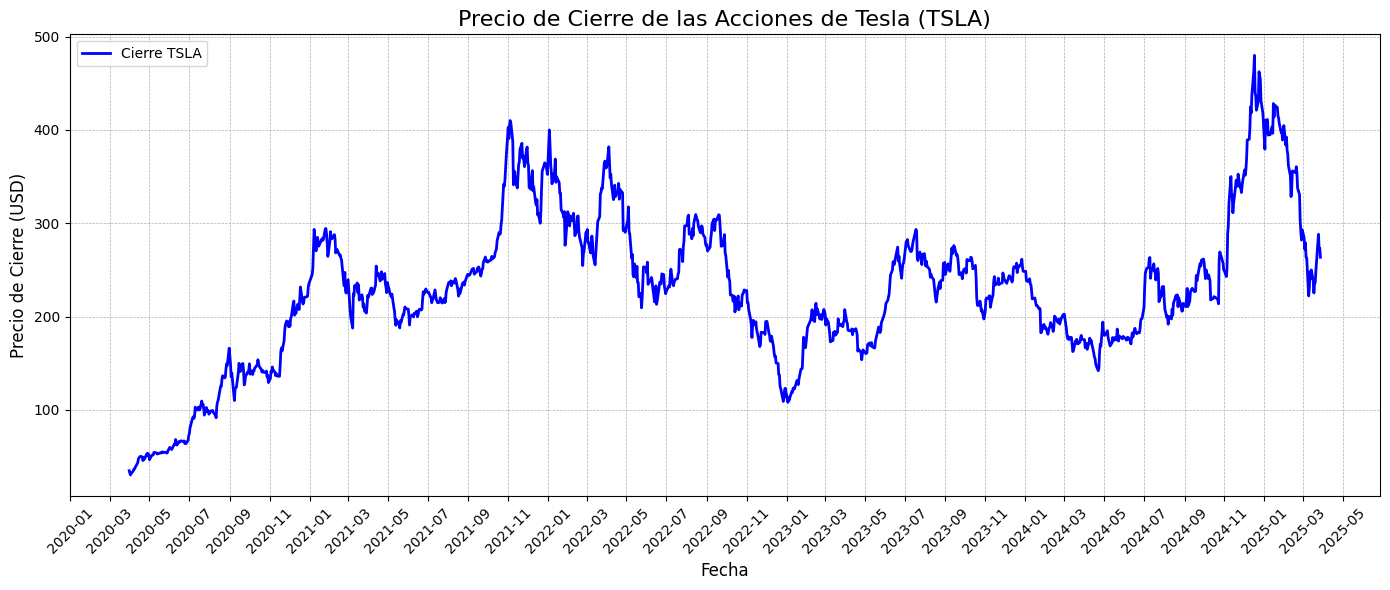

In [ ]:
# Asegurar que el índice sea datetime (y se use como tal para gráficas)
data.index = pd.to_datetime(data.index)

# Configurar la gráfica
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['Close'], color='blue', linewidth=2, label='Cierre TSLA')

# Formato de fechas en el eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Títulos y etiquetas
plt.title('Precio de Cierre de las Acciones de Tesla (TSLA)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio de Cierre (USD)', fontsize=12)
plt.grid(visible=True, linestyle='--', linewidth=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Normalizamos los datos
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data[['Close']])

In [ ]:
print(len(data))

1256


In [ ]:
# Antecedentes para el modelo LSTM
def create_sequences(data, sequence_length=30):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)
# Se emplearan los últimos 12 meses para predecir el siguiente

sequence_length = 30
X, y = create_sequences(data_scaled, sequence_length)

In [ ]:
# Dividimos datos de entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
# Entrenamos el modelo LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(sequence_length, 1), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
history = model.fit(X_train, y_train, epochs=200, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0952 - val_loss: 0.0065
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0063 - val_loss: 0.0060
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0038 - val_loss: 0.0045
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0027 - val_loss: 0.0043
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0027 - val_loss: 0.0047
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0025 - val_loss: 0.0043
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0021 - val_loss: 0.0037
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0023 - val_loss: 0.0037
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0020 - val_loss: 0.0036
Epoch 10/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0018 - val_loss: 0.0032
Epoch 11/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0017 - val_loss: 0.0030
Epoch 12/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


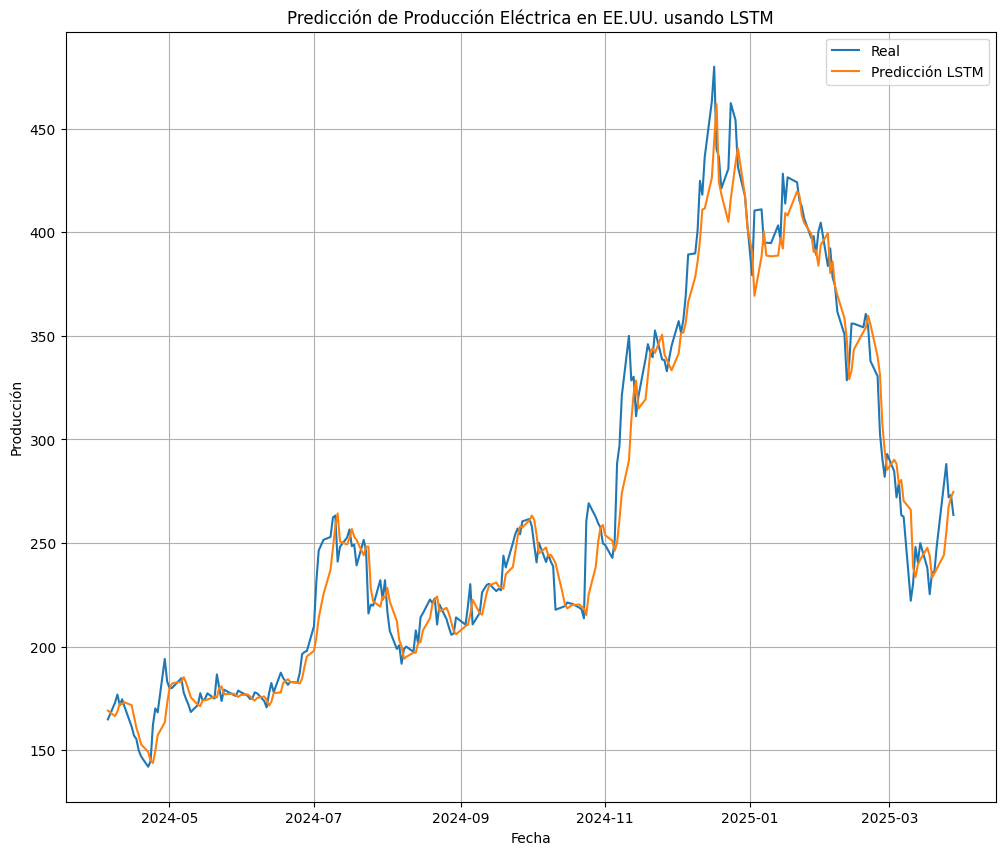

In [ ]:
# Modelamos las predicciones y desescalamos
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

# Visualizamos las predicciones
plt.figure(figsize=(12,10))
plt.plot(data.index[-len(y_test):], y_test_inv, label='Real')
plt.plot(data.index[-len(y_test):], y_pred_inv, label='Predicción LSTM')
plt.title('Predicción de Producción Eléctrica en EE.UU. usando LSTM')
plt.xlabel('Fecha')
plt.ylabel('Producción')
plt.legend()
plt.grid(True)
plt.show()

En este proyecto se utilizó una red LSTM, ya que el precio de las acciones a lo largo del tiempo tienen una naturaleza secuencial, que permite detectar patrones de forma clara y entender al mismo tiempo el tipo de patrón y momento en que puede presentarse, esto porque predice posibles patrones que otros modelos no toman en cuenta.

Al final, se generó un modelo que replica el comportamiento del precio de las acciones de Tesla en el periodo de tiempo considerado. Sin embargo, este comportamiento se ha replicado a destiempo, haciendo muy difícil la predicción de varios de los cambios:  incrementos o disminuciones que puede tener el precio de una acción.
